# Basic functions and Hamiltonian

In [2]:
import matplotlib.pyplot as plt
from Functions import *
from Hamiltonians import *
from FigOMerit_functions import *
from scipy.stats.qmc import *
import os

# Enable LaTeX rendering for text
plt.rcParams.update({
    "text.usetex": True,         # Use LaTeX for text rendering
    "font.family": "serif",      # Use a serif font
    "font.serif": ["Computer Modern"],  # Use Computer Modern for a classic LaTeX look
    "axes.titlesize": 14,        # Title font size
    "axes.labelsize": 12,        # Label font size
    "xtick.labelsize": 10,       # X-tick font size
    "ytick.labelsize": 10,       # Y-tick font size
})


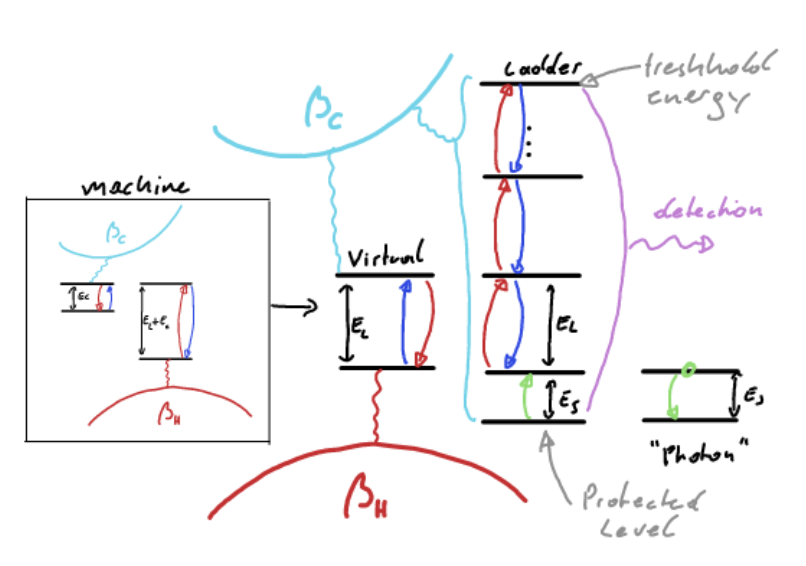

# Dynamics visualised

virt temp: -0.19342071315254955
currten integral 0.5360601108715776
currten integral func 0.5360601108715776
0.0027142879327503727 -0.013300010870480723
0.5366029684642744 2.201390530719265


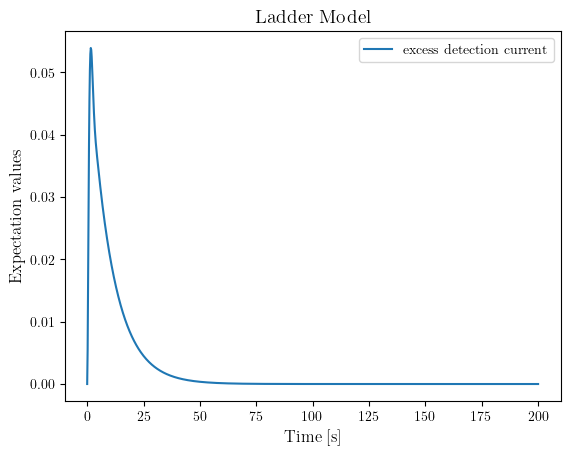

In [2]:
d_l=3
# Interaction strenghts
g_sl=1
g_ml=1

# Energies
#e_l=1/(d_l-3)

e_max=5
e_s=0.1
e_C=1.53
e_l=(e_max-e_s)/(d_l-2)
e_H=e_l+e_C

t_f = 200 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rateM=1
rateB=0.80005522
rateD=1
TH=12.42741673
TC=0.05918583
Tb=TC
Td=TC

k=1

# TV  [-0.19950309]
# TC  [0.05918583]
# TH  [12.42741673]
# rateB  [0.80005522]
# e_C  [1.53]
# e_l  [5.1]
# efficiency  [0.53606878]

print("virt temp:",e_l/(e_H/TH-e_C/TC))

# parameters=[d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB]
# tag_parameters="d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB"
# Total Hamiltonian
H=H0_k(e_s,e_l,e_C,d_l,k)+HI_k(g_sl,g_ml,d_l,k)

# Jump operators
c_ops=c_ops_k(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,d_l,k)

# Observable operators
# e_current_waste=Qobj(np.sum([-(c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[2][l+1]-c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[2][l])*c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[0][l].dag()*c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[0][l]+(c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[2][l+1]-c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[2][l])*c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[1][l].dag()*c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[1][l] for l in range(d_l-1)]))
# e_current_waste=Qobj(np.sum([-(c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[2][l+1]-c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[2][l])*c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[0][l].dag()*c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[0][l]+(c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[2][l+1]-c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[2][l])*c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[1][l].dag()*c_ops_ladder_list_k(rateB,Tb,e_s,e_l,d_l,k)[1][l] for l in range(d_l-1)]))
# e_current_total= Qobj(np.sum([c_ops[i].dag()*c_ops[i] *(-1)**(i+1) for i in range(len(c_ops))]))

# # [tensor(identity(2),identity(d_l),matrix_element(1,1,2)),tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2)),tensor(identity(2),Qobj(np.sum([matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2)),tensor(matrix_element(1,1,2),identity(d_l),identity(2)),c_bath_mi.dag()*c_bath_mi]
# steady_prev_run=steadystate(H,c_ops)
# psi0 = tensor(ptrace(steady_prev_run,0),ptrace(steady_prev_run,1),ptrace(steady_prev_run,2),matrix_element(1,1,2))
times = np.linspace(0., t_f, t_steps)
# hbar=6.62607015*10**(-34)
# real_times=times*6.62607015*10**(-34)/(299792458)
getdyn=get_dynamics_k(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,g_sl,g_ml,d_l,t_f,t_steps,k)
effic=efficiency(getdyn)
e_ops=getdyn[2]
steady_prev_run=getdyn[1]
result = getdyn[0]

fig, ax = plt.subplots()
# plt.plot(times,result.expect[0],label="detection current")
plt.plot(times,result.expect[0]-expect(e_ops[0],steady_prev_run),label="excess detection current")
print("currten integral",np.trapz(np.array(result.expect[0]),dx=t_f/t_steps)-t_f*expect(e_ops[0],steady_prev_run))
print("currten integral func",effic)
# print("tot curr int",(np.trapz(np.array(result.expect[-1]),dx=t_f/t_steps)-t_f*expect(e_ops[-1],steady_prev_run)))
# print("efficiency",(np.trapz(np.array(result.expect[0]),dx=t_f/t_steps)-t_f*expect(e_ops[0],steady_prev_run))/(np.trapz(np.array(result.expect[-1]),times,t_f/t_steps)-t_f*expect(e_ops[-1],steady_prev_run)))
# print("efficiency",(np.trapz(np.array(result.expect[0]),times,t_f/t_steps))/np.trapz(np.array(result.expect[-1]),times,t_f/t_steps))
# plt.plot(times,result.expect[1],label="ready state")
# plt.plot(times,result.expect[-1],label="top")
# plt.plot(times,result.expect[-2],label="waste current")
# plt.plot(times,result.expect[-1],label="tot current")

# plt.plot(times,np.linspace(expect(e_ops[0],steady_prev_run),expect(e_ops[0],steady_prev_run),len(times)),label="current noise floor")
# plt.plot(times,np.linspace(expect(e_ops[-2],steady_prev_run),expect(e_ops[-2],steady_prev_run),len(times)),label="waste noise floor")
# plt.plot(times,np.linspace(expect(e_ops[-1],steady_prev_run),expect(e_ops[-1],steady_prev_run),len(times)),label="tot curr noise floor")

# plt.plot(times,(result.expect[0]-expect(e_ops[0],steady_prev_run))/
#          (result.expect[0]-expect(e_ops[0],steady_prev_run)+result.expect[-1]-expect(e_ops[-1],steady_prev_run)),label="instantaneous $J_D/J_C$ excess")

# plt.plot(times,np.linspace(0.,0.,len(times)),label="0")
# plt.fill_between(times, result.expect[0]- np.sqrt(result.expect[4]-result.expect[0]**2)/2,  result.expect[0] + np.sqrt(result.expect[4]-result.expect[0]**2)/2, color='gray', alpha=0.5, label='Current +- sdt dev /2')

# plt.plot(times,(result.expect[5]+result.expect[2]*e_C)/TC,label="entropy production")
# plt.plot(times, np.linspace(entropy_steady_rate(getdyn),entropy_steady_rate(getdyn),len(times)),label="steady state entropy rate")

# plt.plot(times,result.expect[3],label="Machine heat draw")
#plt.plot(times[200:300],result.expect[0][200:300])
#plt.plot(times[200:300],result.expect[1][200:300])
# plt.plot(times,result.expect[2])
# plt.plot(times,result.expect[3])
# plt.plot(result.expect[4])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Expectation values')
ax.legend(("detection current", "ready state","Machine entropy production", "Machine heat draw"))
plt.title("Ladder Model")
# print(tag_parameters)
# print(parameters)
# print("virtual inverse temperature: ",betaV)
# print("efficiency: ",efficiency)
noise_floor_curr=expect(e_ops[0],steady_prev_run)
noise_floor_waste=expect(e_ops[-1],steady_prev_run)
print(noise_floor_curr,noise_floor_waste)
print(np.sum((result.expect[0]-noise_floor_curr)*t_f/t_steps),np.sum((result.expect[-1]-noise_floor_waste)*t_f/t_steps))
# print("entropy production:", entropy_production(getdyn))
# print("steady entropy rate:", entropy_steady_rate(getdyn))
# print("tot ss curr:",result.expect[-1])
# print(np.sum((result.expect[0]-noise_floor_curr)*t_f/t_steps)/(np.sum((result.expect[0]-noise_floor_curr)*t_f/t_steps)+np.sum((result.expect[-1]-noise_floor_waste)*t_f/t_steps)))
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/transient_dyn_1.eps', format='eps')

# Figures of Merit plots

## Generate datasets

In [2]:
#######################################################################
### Variables Most relevant for below (the ones that we investigate)###
#######################################################################

d_l=5 # Ladder dim
e_max=5 # Energy of most excited level of ladder (threshold energy)
e_s=0.1 # System (photon) energy
TH=10 # Hot bath temperature
TC=0.1 # Cold bath temperature
rateB=0.1 # Dissipator rate Ladder-cold bath

#######################################################################
#######################################################################

# Interaction strenghts
g_sl=1 # system-ladder interaction strenght
g_ml=1 # machine-ladder interacton strength

# Energies
e_C=0.8 # Cold bath gap (determines together with system energy the hot bath gap)

t_f = 200 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rateM=1 # Dissipator rate machine-baths
rateD=1 # dissipation rate detection channel
Tb=TC # Ladder bath temperature
Td=TC # Detection channel temperature


In [15]:
#generate plots of all figures of merit over RateB for a bunch of different dimensions

FOM_RB_dl_list=[[get_all_figures_of_merit(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max-e_s)/(d_l-2),g_sl,g_ml,d_l,t_f,t_steps))
             for rateB in np.linspace(0.001,1,30)]
             for d_l in range(3,34,5)]
qsave(FOM_RB_dl_list,"FOM_RB_dl_list")

In [16]:
#generate plots of all figures of merit over ladder dim for a bunch of different ladder-bath couplings rateB

FOM_dl_RB_list=[[get_all_figures_of_merit(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),g_sl,g_ml,d_l,t_f,t_steps))
             for d_l in range(3,41)]
             for rateB in np.linspace(0.001,1,5)]

qsave(FOM_dl_RB_list,"FOM_dl_RB_list")


In [15]:
#generate plots of all figures of merit over ladder dim for a bunch of different hot temperatures

FOM_dl_TH_list=[[get_all_figures_of_merit(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),g_sl,g_ml,d_l,t_f,t_steps))
             for d_l in range(3,34)]
             for TH in np.linspace(0.1,5,5)]

qsave(FOM_dl_TH_list,"FOM_dl_TH_list")

In [47]:
#generate plots of all figures of merit over TC for a bunch of different TH

FOM_TC_TH_list=[[get_all_figures_of_merit(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),g_sl,g_ml,d_l,t_f,t_steps))
             for TC in np.linspace(0.01,TH,40)]
             for TH in np.linspace(0.01,15,20)]

qsave(FOM_TC_TH_list,"FOM_TC_TH_list")


In [14]:
#generate plots of all figures of merit over E_max for a bunch of different TH

FOM_Emax_list=[get_all_figures_of_merit(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),g_sl,g_ml,d_l,t_f,t_steps))
             for d_l in range(3,20)]

qsave(FOM_Emax_list,"FOM_Emax_list")

## Generate random sampling data set
Sampling from uniform distributions first, and later maybe from Latin Hypercube sampling

Parameters that are random sampled and parameter range

$d\in [3,40]$

$R_B\in [0.01,2]$

$T_H \in [0.01, 10]$

$T_C \in [0.01,10]$ with the constraint that $\frac{E_C}{E_H}T_H\geq T_C$ to stay in the heat engine regime

$E_{max} \in [0.1,10]$ (will be fixed for now at $5$)

$E_f \in [0.01,1]$ (will be fixed for now at $0.1$)



### Latin Hyper Cube sampling and filtering
Here's an example of how we random sample using the Latin Hypercube technique and then filter out the valid samples

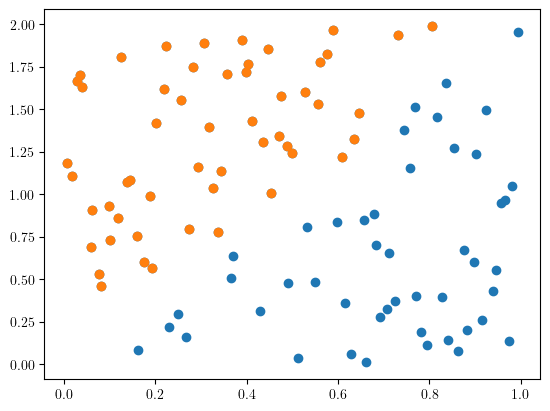

In [2]:



sampler=LatinHypercube(2)
samples=np.array(sampler.random(n=100))

scaled_samples = scale(samples, [0, 0], [1,2])
plt.scatter(scaled_samples[:,0],scaled_samples[:,1])
filtered_samples = scaled_samples[scaled_samples[:, 1] > 2 * scaled_samples[:, 0] ]
plt.scatter(filtered_samples[:,0],filtered_samples[:,1])

### Generating Latin Hypercube random sample data sets

In [3]:
#######################################################################
### Variables Most relevant for below (the ones that we investigate)###
#######################################################################

parameters = {
    # General parameters
    "d_l": 3,         # Ladder dimension
    "e_max": 5,       # Energy of most excited level of ladder (threshold energy)
    "e_s": 0.1,       # System (photon) energy
    "TH": 10,         # Hot bath temperature
    "TC": 0.1,        # Cold bath temperature
    "rateB": 0.1,     # Dissipator rate Ladder-cold bath

    # Interaction strengths
    "g_sl": 1,        # System-ladder interaction strength
    "g_ml": 1,        # Machine-ladder interaction strength

    # Energies
    "e_C": 0.8,       # Cold bath gap
    "e_C_factor": 0.3, # Factor for cold bath gap calculation
    "t_f": 200,       # Final time
    "t_steps": 1000,   # Number of timesteps

    # Jump rates
    "rateM": 1,       # Dissipator rate machine-baths
    "rateD": 1,       # Dissipation rate detection channel
    "rateB": 0.8,     # Thermalizing rate ladder-bath
    "Tb": 0.1,        # Ladder bath temperature
    "Td": 0.1,        # Detection channel temperature

    # Constant k
    "k": 1
}
parameters["e_l"]=(parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2)
parameters["TV"]=TV_from_TH_TC(parameters["TH"],parameters["TC"],parameters["e_l"]*parameters["e_C_factor"],parameters["e_l"])

# Assigning dictionary values to variables
d_l = parameters["d_l"]
e_max = parameters["e_max"]
e_s = parameters["e_s"]
TH = parameters["TH"]
TC = parameters["TC"]
rateB = parameters["rateB"]

g_sl = parameters["g_sl"]
g_ml = parameters["g_ml"]

e_C = parameters["e_C"]
e_C_factor = parameters["e_C_factor"]
t_f = parameters["t_f"]
t_steps = parameters["t_steps"]

rateM = parameters["rateM"]
rateD = parameters["rateD"]
Tb = parameters["Tb"]
Td = parameters["Td"]

k = parameters["k"]


In [169]:


e_C=e_C_factor*e_l
parameters["TC"]=0.05
k=1
data=[]
for TV in np.linspace(-1,-0.05,200):

    parameters["TH"]=TH_from_TV_TC(TV,parameters["TC"],parameters["e_C"],
                                   (parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2))
    if parameters["TH"] >=0:
        data.append(get_all_figures_of_merit(
        get_dynamics_k(
            parameters["rateM"],
            parameters["rateB"],
            parameters["rateD"],
            parameters["TH"],
            parameters["TC"],
            parameters["Tb"],
            parameters["Td"],
            parameters["e_s"],
            ((parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2))*parameters["e_C_factor"],
            (parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2),
            parameters["g_sl"],
            parameters["g_ml"],
            parameters["d_l"],
            parameters["t_f"],
            parameters["t_steps"],
            parameters["k"]
            )
            ))
        # data.append(get_all_figures_of_merit(get_dynamics_k(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,g_sl,g_ml,d_l,t_f,t_steps,k)))

In [8]:
def get_FoM_vari_one_parameter(param_dict,param_str,param_range): # exception: e_l can not be used as parameter for change
    data=[]
    parameters=param_dict.copy()
    for param in param_range:
        parameters[param_str]=param
        parameters["e_l"]=(parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2)
        if param_str=="TV":
            parameters["TH"]=TH_from_TV_TC(parameters["TV"],parameters["TC"],parameters["e_C"],
                                        (parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2))
        if param_str=="TH" or param_str=="TC":
            parameters["TV"]=TV_from_TH_TC(parameters["TH"],parameters["TC"],parameters["e_l"]*parameters["e_C_factor"],parameters["e_l"])
        parameters[param_str]=param
        if (parameters["TH"] >=0 and parameters["TV"]<=0):
            data.append(get_all_figures_of_merit(
            get_dynamics_k(
                parameters["rateM"],
                parameters["rateB"],
                parameters["rateD"],
                parameters["TH"],
                parameters["TC"],
                parameters["Tb"],
                parameters["Td"],
                parameters["e_s"],
                parameters["e_l"]*parameters["e_C_factor"],
                (parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2),
                parameters["g_sl"],
                parameters["g_ml"],
                parameters["d_l"],
                parameters["t_f"],
                parameters["t_steps"],
                parameters["k"]
                )
                ))
    return(data)

In [9]:
data=[]
for TC in [0.05,0.1,0.2,0.4]:
    parameters["TC"]=TC
    data.append(get_FoM_vari_one_parameter(parameters,"TV",np.linspace(-10,0.05,200)))

NameError: name 'e_l' is not defined

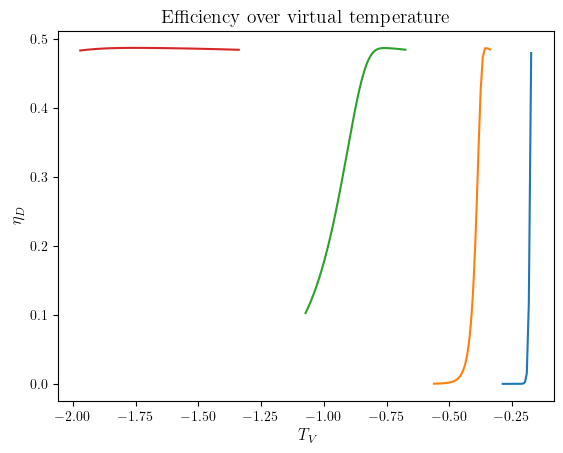

In [10]:
fig, ax = plt.subplots()
ax.set_xlabel("$T_V$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')
plt.title("Efficiency over virtual temperature")
[plt.plot(np.array(data[i])[:,out_index("TV")],np.array(data[i])[:,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")])) for i in range(len(data))]
# Add a caption
# caption = (r"\textbf{Figure 1.} parameters: "
#            fr"$R_M$={rateM}, $R_B$={rateB}, $R_D$={rateD}, $T_H$={TH}, $T_C$={TC}, $T_B$={Tb}, $T_D$={Td},"
#            r" \\ \quad"fr"$e_S$={e_s}, $e_C${e_C:.3f}, $e_l$={e_l}, "r"$g_{sl}$="fr"{g_sl}, "r"$g_{ml}$="fr"{g_ml}, $d_l$={d_l}, $t_f=${t_f}, "r"$t_\mathrm{steps}=$"fr"{t_steps}, $k=${k}")
caption = (
    r"\textbf{Figure 1.} Parameters: \\"
    fr"$R_M={rateM}, R_B={rateB}, R_D={rateD}, T_C={TC}, T_B={Tb}, T_D={Td},$ \\"
    r"\quad "
    fr"$e_S={e_s}, e_C={e_C:.3f}, e_l={e_l}, g_{{sl}}={g_sl}, g_{{ml}}={g_ml}, d_l={d_l},$ \\"
    fr"$t_f={t_f}, t_{{\mathrm{{steps}}}}={t_steps}, k={k}$"
)

plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)
plt.legend()

NameError: name 'e_l' is not defined

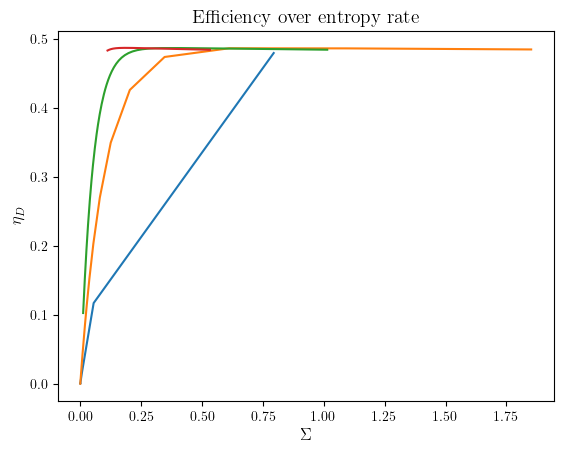

In [25]:
fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$\eta_D$")

plt.title("Efficiency over entropy rate")
[plt.plot(np.array(data[i])[:,out_index("entropy rate")],np.array(data[i])[:,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")])) for i in range(len(data))]
# Add a caption
# caption = (r"\textbf{Figure 1.} parameters: "
#            fr"$R_M$={rateM}, $R_B$={rateB}, $R_D$={rateD}, $T_H$={TH}, $T_C$={TC}, $T_B$={Tb}, $T_D$={Td},"
#            r" \\ \quad"fr"$e_S$={e_s}, $e_C${e_C:.3f}, $e_l$={e_l}, "r"$g_{sl}$="fr"{g_sl}, "r"$g_{ml}$="fr"{g_ml}, $d_l$={d_l}, $t_f=${t_f}, "r"$t_\mathrm{steps}=$"fr"{t_steps}, $k=${k}")
caption = (
    r"\textbf{Figure 1.} Parameters: \\"
    fr"$R_M={rateM}, R_B={rateB}, R_D={rateD}, T_C={TC}, T_B={Tb}, T_D={Td},$ \\"
    r"\quad "
    fr"$e_S={e_s}, e_C={e_C:.3f}, e_l={e_l}, g_{{sl}}={g_sl}, g_{{ml}}={g_ml}, d_l={d_l},$ \\"
    fr"$t_f={t_f}, t_{{\mathrm{{steps}}}}={t_steps}, k={k}$"
)

plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)
plt.legend()

NameError: name 'e_l' is not defined

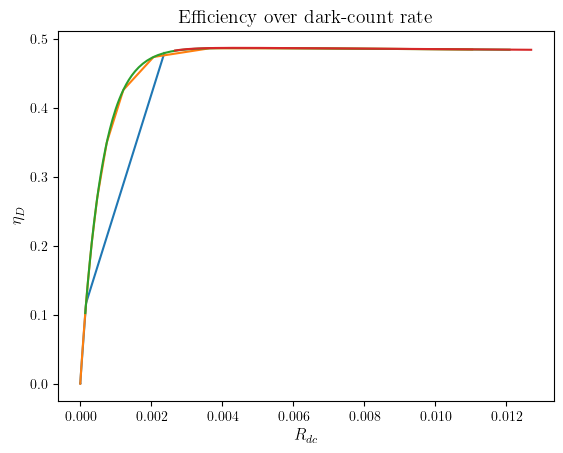

In [26]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_{dc}$")
ax.set_ylabel("$\eta_D$")
plt.title("Efficiency over dark-count rate")
for i in range(len(data)):
    plt.plot(np.array(data[i]) [:,out_index("dark count rate")],np.array(data[i])[:,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))
# Add a caption
# caption = (r"\textbf{Figure 1.} parameters: "
#            fr"$R_M$={rateM}, $R_B$={rateB}, $R_D$={rateD}, $T_H$={TH}, $T_C$={TC}, $T_B$={Tb}, $T_D$={Td},"
#            r" \\ \quad"fr"$e_S$={e_s}, $e_C${e_C:.3f}, $e_l$={e_l}, "r"$g_{sl}$="fr"{g_sl}, "r"$g_{ml}$="fr"{g_ml}, $d_l$={d_l}, $t_f=${t_f}, "r"$t_\mathrm{steps}=$"fr"{t_steps}, $k=${k}")
caption = (
    r"\textbf{Figure 1.} Parameters: \\"
    fr"$R_M={rateM}, R_B={rateB}, R_D={rateD}, T_C={TC}, T_B={Tb}, T_D={Td},$ \\"
    r"\quad "
    fr"$e_S={e_s}, e_C={e_C:.3f}, e_l={e_l}, g_{{sl}}={g_sl}, g_{{ml}}={g_ml}, d_l={d_l},$ \\"
    fr"$t_f={t_f}, t_{{\mathrm{{steps}}}}={t_steps}, k={k}$"
)

plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)
plt.legend()

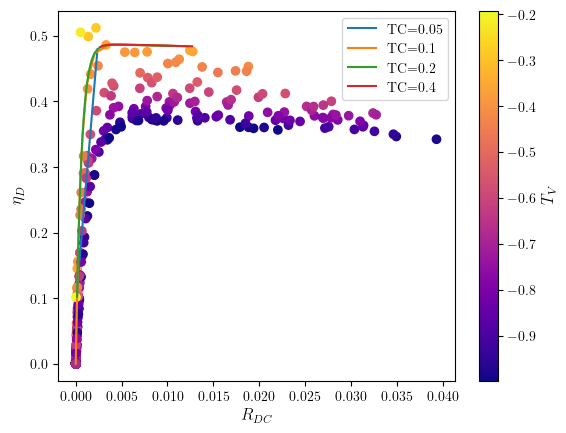

In [23]:
# condition = (dset[:, out_index("TC")] < 0.15) & (dset[:, out_index("TC")] >= 0.12)
dset=qload("FOM_fixed_d_RB_variing_TC_TV")
dset=np.array(dset)
# condition =  ((dset[:, out_index("rateB")] < 0.901) & (0.9<dset[:, out_index("rateB")]) )
# condition &= dset[:, out_index("d_l")] == 3
# condition &=((dset[:,out_index("TV")]<-0.2) & (dset[:,out_index("TV")]>-0.23)) | ((dset[:,out_index("TV")]<-0.8) & (dset[:,out_index("TV")]>-0.83))
# condition =  (dset[:, out_index("rateB")] <  0.163)& (dset[:, out_index("rateB")] >  0.16)

# condition =  (dset[:, out_index("T")] <  0.22)& (dset[:, out_index("rateB")] >  0.2)

condition = dset[:, out_index("k")] == 1
# condition &=(dset[:, out_index("TV")] > -0.2)
# condition &=(dset[:, out_index("efficiency")] > 0.53)
condition &=  (dset[:, out_index("rateB")] <  0.801)& (dset[:, out_index("rateB")] >  0.8)
FOM_LHC_sampling=dset
FOM_LHC_sampling=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$R_{DC}$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')
plt.title("")
scatter=plt.scatter(np.array(FOM_LHC_sampling)[:,out_index("dark count rate")],
                    np.array(FOM_LHC_sampling)[:,out_index("efficiency")],
                c=np.array(FOM_LHC_sampling)[:,out_index("TV")],cmap='plasma')

for i in range(len(data)):
    plt.plot(np.array(data[i]) [:,out_index("dark count rate")],np.array(data[i])[:,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))


plt.colorbar(scatter, label="$T_V$")
plt.legend()

In [323]:
print("TV ", np.array(dset[condition])[:,out_index("TV")])
print("TC ",np.array(dset[condition])[:,out_index("TC")])
print("TH ",np.array(dset[condition])[:,out_index("TH")])
print("rateB ",np.array(dset[condition])[:,out_index("rateB")])
print("e_C ",np.array(dset[condition])[:,out_index("e_C")])
print("e_l ",np.array(dset[condition])[:,out_index("e_l")])
print("efficiency ",np.array(dset[condition])[:,out_index("efficiency")])
print("dark count rate ",np.array(dset[condition])[:,out_index("dark count rate")])


TV  [-0.19950309]
TC  [0.05918583]
TH  [12.42741673]
rateB  [0.80005522]
e_C  [1.53]
e_l  [5.1]
efficiency  [0.53606878]
dark count rate  [0.00269013]


In [349]:
TH_from_TV_TC(0.045577653350688925,0.05918583,1.53,5.1)

0.025916943746676593

In [350]:
TV_from_TH_TC(0.025916943746676593,12.42741673,1.53,5.1)

0.019945709670029975

In [339]:
efficiency(get_dynamics_k(
                1,
                0.80005522,
                1,
                12.42741673,
                0.05,
                0.05,
                0.05,
                0.1,
                1.53,
                5.1,
                1,
                1,
                3,
                100,
                1000,
                1
                ))

0.5448267951855484

In [331]:
TH_from_TV_TC(-0.19950309,0.059,parameters["e_C"],
                                        (parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2))

-0.35820820540469755

In [341]:
parameters["TV"]=-0.1934207171703263
parameters["TC"]=0.05918583
parameters["rateB"]=0.80005522
parameters["TH"]=TH_from_TV_TC(parameters["TV"],parameters["TC"],parameters["e_l"]*parameters["e_C_factor"],
                                        (parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2))

testi=get_all_figures_of_merit(
            get_dynamics_k(
                parameters["rateM"],
                parameters["rateB"],
                parameters["rateD"],
                parameters["TH"],
                parameters["TC"],
                parameters["Tb"],
                parameters["Td"],
                parameters["e_s"],
                parameters["e_l"]*parameters["e_C_factor"],
                (parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2),
                parameters["g_sl"],
                parameters["g_ml"],
                parameters["d_l"],
                parameters["t_f"],
                parameters["t_steps"],
                parameters["k"]
                )
                )
print("TV ", parameters["TV"])
print("TC ", parameters["TC"])
print("TH ", parameters["TH"])
print("rateB ", parameters["rateB"])
print("e_C ", parameters["e_l"]*parameters["e_C_factor"])
print("e_l ", (+parameters["e_s"] + parameters["e_max"]) / (parameters["d_l"] - 2))
np.array(testi)[out_index("efficiency")]

TV  -0.1934207171703263
TC  0.05918583
TH  -6.910428912695934
rateB  0.80005522
e_C  1.5299999999999998
e_l  5.1


0.48208009148827724

In [340]:
TV_from_TH_TC(12.427404090606945,0.05918583,1.5299999999999998,4.9)

-0.1934207171703263

In [8]:
#Sampling ranges
d_range=[3,3]
R_B_range=[0.8,0.801]
T_C_range=[0.05,1]
T_V_range=[-1,-0.02]

k=1

n=0
while n<5000:
    sample_set=np.array(generate_sample_set_d_TC_TV_RB(d_range,R_B_range,T_C_range,T_V_range,e_s,e_C_factor,e_max,10))
    dset=generate_dataset_d_TC_TV_RB(sample_set,"FOM_fixed_d_RB_variing_TC_TV",rateM,rateD,e_s,e_C_factor,e_max,g_sl,g_ml,t_f,t_steps,k)
    print(f"sample set no.{n}, dataset size {np.array(dset).shape}", end="\r", flush=True)
    n+=1

KeyboardInterrupt: 

#### Scatter Plots

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


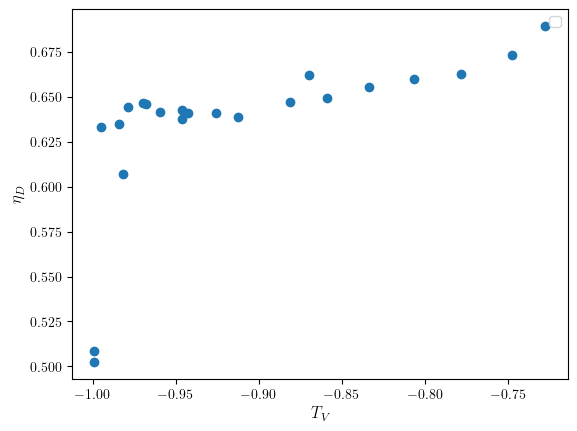

In [60]:
# condition = (dset[:, out_index("TC")] < 0.15) & (dset[:, out_index("TC")] >= 0.12)
dset=qload("FOM_LHC_sampling_cummulative")
dset=np.array(dset)
# condition =  ((dset[:, out_index("rateB")] < 0.901) & (0.9<dset[:, out_index("rateB")]) )
# condition &= dset[:, out_index("d_l")] == 3
# condition &=((dset[:,out_index("TV")]<-0.2) & (dset[:,out_index("TV")]>-0.23)) | ((dset[:,out_index("TV")]<-0.8) & (dset[:,out_index("TV")]>-0.83))
# (dset[:, out_index("TV")] > -0.6)&(dset[:, out_index("TV")] <  -0.55)&
condition =  (dset[:, out_index("rateB")] <  0.163)& (dset[:, out_index("rateB")] >  0.16)
condition &=  (dset[:, out_index("TC")] <  0.3)& (dset[:, out_index("TC")] >  0.2)

# condition =  (dset[:, out_index("T")] <  0.22)& (dset[:, out_index("rateB")] >  0.2)

condition &= dset[:, out_index("k")] == 1

FOM_LHC_sampling=dset
FOM_LHC_sampling=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$T_V$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')
plt.title("")
scatter=plt.scatter(np.array(FOM_LHC_sampling)[:,out_index("TV")],
                    np.array(FOM_LHC_sampling)[:,out_index("efficiency")],
#                c=np.array(FOM_LHC_sampling)[:,out_index("TC")],cmap='plasma'
                )

# plt.colorbar(scatter, label="$TV$")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


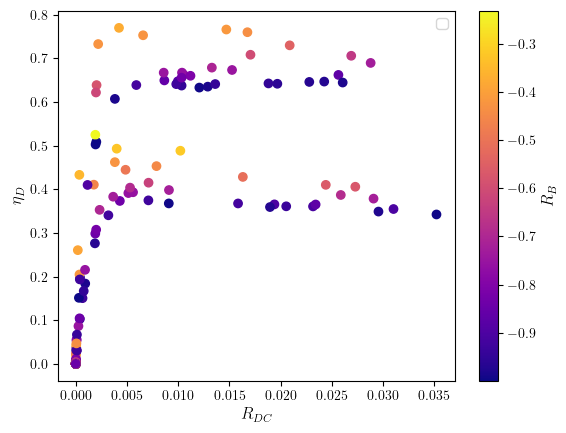

In [48]:
# condition = (dset[:, out_index("TC")] < 0.15) & (dset[:, out_index("TC")] >= 0.12)
dset=qload("FOM_LHC_sampling_cummulative")
dset=np.array(dset)
# condition =  ((dset[:, out_index("rateB")] < 0.901) & (0.9<dset[:, out_index("rateB")]) )
# condition &= dset[:, out_index("d_l")] == 3
# condition &=((dset[:,out_index("TV")]<-0.2) & (dset[:,out_index("TV")]>-0.23)) | ((dset[:,out_index("TV")]<-0.8) & (dset[:,out_index("TV")]>-0.83))
# (dset[:, out_index("TV")] > -0.6)&(dset[:, out_index("TV")] <  -0.55)&
condition =  (dset[:, out_index("rateB")] <  0.163)& (dset[:, out_index("rateB")] >  0.16)
condition |=  (dset[:, out_index("rateB")] <  0.813)& (dset[:, out_index("rateB")] >  0.81)

# condition =  (dset[:, out_index("T")] <  0.22)& (dset[:, out_index("rateB")] >  0.2)

condition &= dset[:, out_index("k")] == 1

FOM_LHC_sampling=dset
FOM_LHC_sampling=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$R_{DC}$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')
plt.title("")
scatter=plt.scatter(np.array(FOM_LHC_sampling)[:,out_index("dark count rate")],
                    np.array(FOM_LHC_sampling)[:,out_index("efficiency")],
                c=np.array(FOM_LHC_sampling)[:,out_index("TV")],cmap='plasma')

plt.colorbar(scatter, label="$R_B$")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


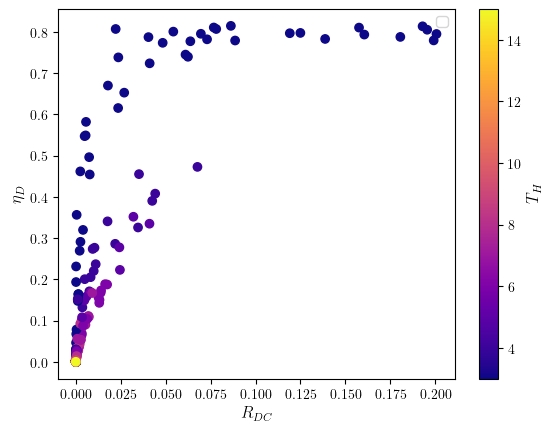

In [43]:
# condition = (dset[:, out_index("TC")] < 0.15) & (dset[:, out_index("TC")] >= 0.12)
dset=qload("FOM_LHC_sampling_cummulative")
dset=np.array(dset)
# condition =  ((dset[:, out_index("rateB")] < 0.901) & (0.9<dset[:, out_index("rateB")]) )
# condition &= dset[:, out_index("d_l")] == 3
# condition &=((dset[:,out_index("TV")]<-0.2) & (dset[:,out_index("TV")]>-0.23)) | ((dset[:,out_index("TV")]<-0.8) & (dset[:,out_index("TV")]>-0.83))
# (dset[:, out_index("TV")] > -0.6)&(dset[:, out_index("TV")] <  -0.55)&
# condition =  (dset[:, out_index("rateB")] <  0.202)& (dset[:, out_index("rateB")] >  0.2)

FOM_LHC_sampling=dset
FOM_LHC_sampling=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$R_{DC}$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')
plt.title("")
scatter=plt.scatter(np.array(FOM_LHC_sampling)[:,out_index("dark count rate")],
                    np.array(FOM_LHC_sampling)[:,out_index("efficiency")],
                c=np.array(FOM_LHC_sampling)[:,out_index("d_l")],cmap='plasma')

plt.colorbar(scatter, label="$T_H$")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


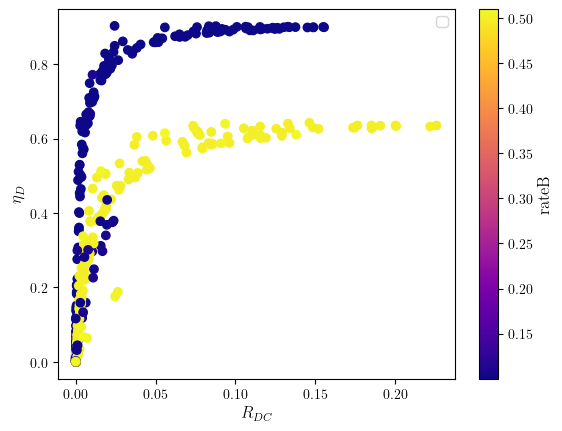

In [64]:
# condition = (dset[:, out_index("TC")] < 0.15) & (dset[:, out_index("TC")] >= 0.12)
dset=qload("FOM_LHC_sampling_cummulative")
dset=np.array(dset)
# condition =  ((dset[:, out_index("rateB")] < 0.901) & (0.9<dset[:, out_index("rateB")]) )

# condition &=((dset[:,out_index("TV")]<-0.2) & (dset[:,out_index("TV")]>-0.23)) | ((dset[:,out_index("TV")]<-0.8) & (dset[:,out_index("TV")]>-0.83))
# (dset[:, out_index("TV")] > -0.6)&(dset[:, out_index("TV")] <  -0.55)&
# condition =  (dset[:, out_index("rateB")] <  0.2)
condition =  (dset[:, out_index("rateB")] <  0.11)& (dset[:, out_index("rateB")] >  0.1)
condition |=  (dset[:, out_index("rateB")] <  0.51)& (dset[:, out_index("rateB")] >  0.5)
# condition &= dset[:, out_index("d_l")] == 3
FOM_LHC_sampling=dset
FOM_LHC_sampling=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$R_{DC}$")
ax.set_ylabel("$\eta_D$")

colourbar="rateB"

# ax.set_yscale('log')
# ax.set_xscale('log')
plt.title("")
scatter=plt.scatter(np.array(FOM_LHC_sampling)[:,out_index("dark count rate")],
                    np.array(FOM_LHC_sampling)[:,out_index("efficiency")],
                c=np.array(FOM_LHC_sampling)[:,out_index(colourbar)],cmap='plasma')

plt.colorbar(scatter, label=colourbar)
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


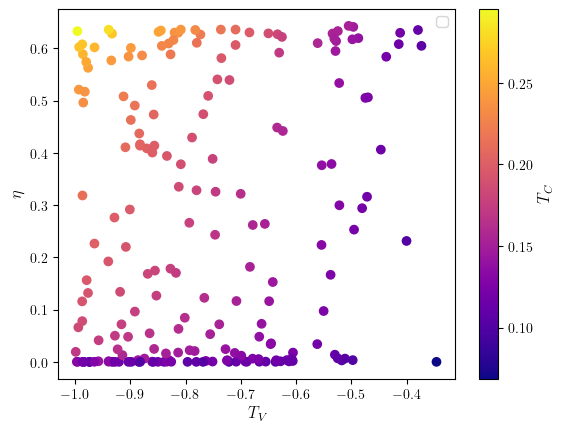

In [116]:
# condition = (dset[:, out_index("TC")] < 0.15) & (dset[:, out_index("TC")] >= 0.12)
dset=qload("FOM_LHC_sampling_cummulative")
dset=np.array(dset)
# condition =  ((dset[:, out_index("rateB")] < 0.101) & (0.1<dset[:, out_index("rateB")]) )| (dset[:, out_index("rateB")] < 0.501) & (0.5<dset[:, out_index("rateB")])
# condition=(dset[:, out_index("efficiency")] > 0.4)| (dset[:, out_index("efficiency")] < 0.2)
# condition &=((dset[:,out_index("TV")]<-0.2) & (dset[:,out_index("TV")]>-0.23)) | ((dset[:,out_index("TV")]<-0.8) & (dset[:,out_index("TV")]>-0.83))
condition=(dset[:,out_index("d_l")]==3)
condition &=  ((dset[:, out_index("rateB")] < 0.501) & (0.5<dset[:, out_index("rateB")]) )
condition |  ((dset[:, out_index("rateB")] < 0.501) & (0.5<dset[:, out_index("rateB")]) )
# FOM_LHC_sampling=dset
FOM_LHC_sampling=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$T_V$")
ax.set_ylabel("$\eta$")
# ax.set_yscale('log')
# ax.set_xscale('log')
plt.title("")
scatter=plt.scatter(np.array(FOM_LHC_sampling)[:,out_index("TV")],
                    np.array(FOM_LHC_sampling)[:,out_index("efficiency")],
                c=np.array(FOM_LHC_sampling)[:,out_index("TC")],cmap='plasma')

plt.colorbar(scatter, label="$T_C$")
plt.legend()

/tmp/ipykernel_34239/2615574492.py:22: RuntimeWarning: divide by zero encountered in log
  c=np.log(np.array(FOM_LHC_sampling)[:,out_index("efficiency")]),cmap='plasma')
/tmp/ipykernel_34239/2615574492.py:22: RuntimeWarning: invalid value encountered in log
  c=np.log(np.array(FOM_LHC_sampling)[:,out_index("efficiency")]),cmap='plasma')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


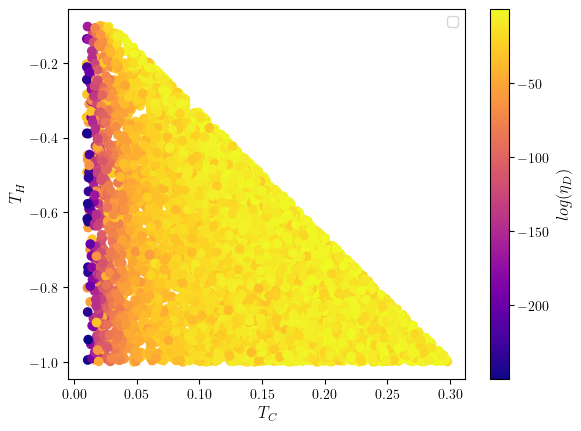

In [92]:
# # condition = (dset[:, out_index("TC")] < 0.15) & (dset[:, out_index("TC")] >= 0.12)
# dset=qload("FOM_LHC_sampling_cummulative")
# dset=np.array(dset)
# # condition =  ((dset[:, out_index("rateB")] < 0.101) & (0.1<dset[:, out_index("rateB")]) )| (dset[:, out_index("rateB")] < 0.501) & (0.5<dset[:, out_index("rateB")])
# condition=dset[:, out_index("d_l")] == 3
# # condition &=((dset[:,out_index("TV")]<-0.2) & (dset[:,out_index("TV")]>-0.23)) | ((dset[:,out_index("TV")]<-0.8) & (dset[:,out_index("TV")]>-0.83))


# FOM_LHC_sampling=dset
# # FOM_LHC_sampling=dset[condition]



# fig, ax = plt.subplots()
# ax.set_xlabel("$T_C$")
# ax.set_ylabel("$T_H$")
# # ax.set_yscale('log')
# # ax.set_xscale('log')
# plt.title("")
# scatter=plt.scatter(np.array(FOM_LHC_sampling)[:,out_index("TC")],
#                     np.array(FOM_LHC_sampling)[:,out_index("TV")],
#                 c=np.log(np.array(FOM_LHC_sampling)[:,out_index("efficiency")]),cmap='plasma')

# plt.colorbar(scatter, label="$log(\eta_D)$")
# plt.legend()

## Load datasets

In [5]:
FOM_RB_dl_list_loaded=np.array(qload("FOM_RB_dl_list_secure"))
FOM_dl_RB_list_loaded=np.array(qload("FOM_dl_RB_list_secure"))
FOM_TC_TH_list_loaded=np.array(qload("FOM_TC_TH_list_secure"))
FOM_Emax_list_loaded=np.array(qload("FOM_Emax_list_secure"))
FOM_dl_TH_list_loaded=np.array(qload("FOM_dl_TH_list_secure"))


In [9]:
# plt.plot(FOM_RB_dl_list_loaded[2,:,0])
FOM_dl_RB_list_loaded.shape

(5, 38, 4)

## Plot Data

### Parameter $R_B$

#### y axis: $\eta_D$

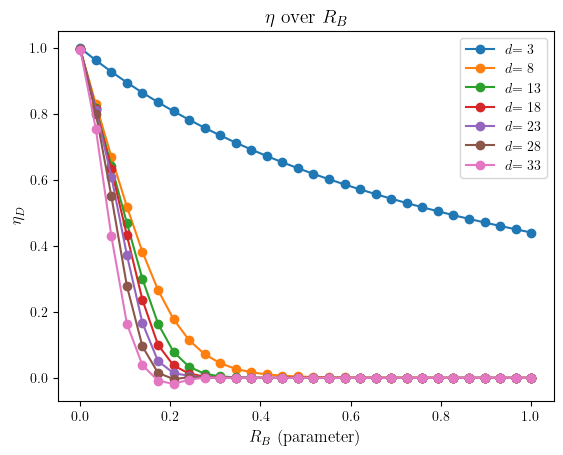

In [57]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_B $ (parameter)")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta$ over $R_B$")
[plt.plot(np.array(FOM_RB_dl_list_loaded)[i,:,7],np.array(FOM_RB_dl_list_loaded)[i,:,0],marker="o",label="$d$= "+str(int(np.array(FOM_RB_dl_list_loaded)[i,0,18]))) for i in range(0,7)]
plt.legend()

##### FOM plots

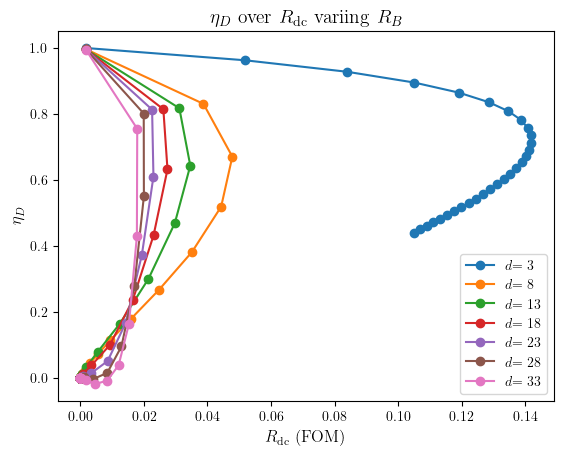

In [58]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_\mathrm{dc}$ (FOM)")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta_D$ over $R_\mathrm{dc}$ variing $R_B$")
[plt.plot(np.array(FOM_RB_dl_list_loaded)[i,:,1],np.array(FOM_RB_dl_list_loaded)[i,:,0],marker="o",label="$d$= "+str(int(np.array(FOM_RB_dl_list_loaded)[i,0,18]))) for i in range(0,7)]
plt.legend()

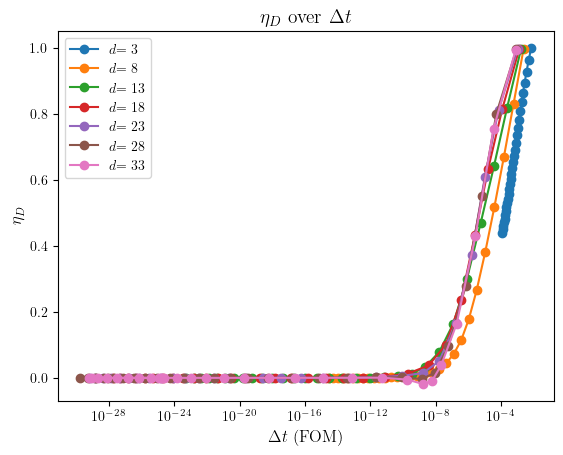

In [61]:
fig, ax = plt.subplots()
ax.set_xlabel("$\Delta t$ (FOM)")
ax.set_xscale("log")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta_D$ over $\Delta t$")
[plt.plot(np.array(FOM_RB_dl_list_loaded)[i,:,2],np.array(FOM_RB_dl_list_loaded)[i,:,0],marker="o",label="$d$= "+str(int(np.array(FOM_RB_dl_list_loaded)[i,0,18]))) for i in range(0,7)]
plt.legend()

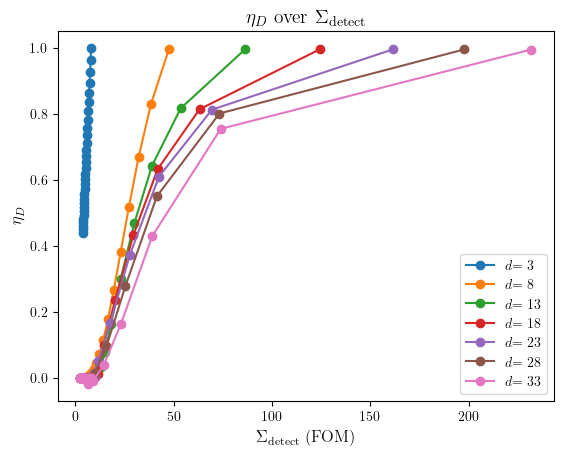

In [62]:
fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma_\mathrm{detect}$ (FOM)")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta_D$ over $\Sigma_\mathrm{detect}$")
[plt.plot(np.array(FOM_RB_dl_list_loaded)[i,:,3],np.array(FOM_RB_dl_list_loaded)[i,:,0],marker="o",label="$d$= "+str(int(np.array(FOM_RB_dl_list_loaded)[i,0,18]))) for i in range(0,7)]
plt.legend()

### Parameter $d_L$ variation $R_B$

#### y axis: $\eta_D$

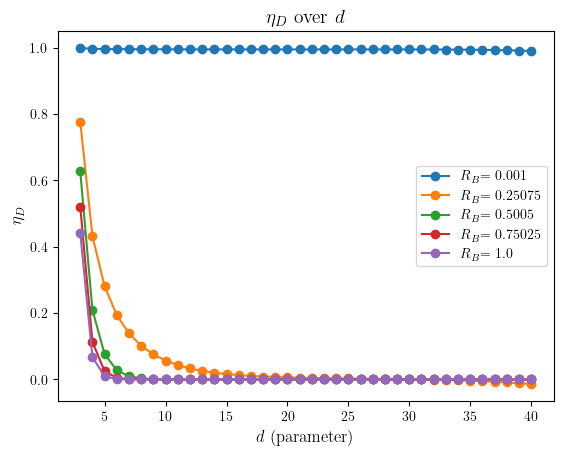

In [48]:
fig, ax = plt.subplots()
ax.set_xlabel("$d $ (parameter)")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta_D$ over $d$")
[plt.plot(np.array(FOM_dl_RB_list_loaded)[i,:,18],np.array(FOM_dl_RB_list_loaded)[i,:,0],marker="o",label="$R_B$= "+str(np.array(FOM_dl_RB_list_loaded)[i,0,out_index("rateB")]))
 for i in range(0,len(FOM_dl_RB_list_loaded[:,0,out_index("rateB")]))]
plt.legend()

##### FOM plots

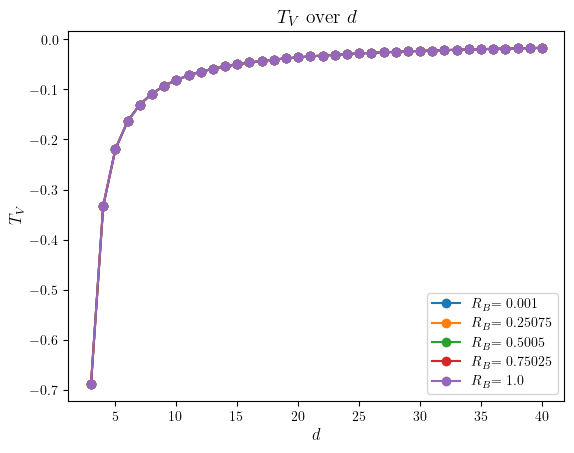

In [ ]:
# data=neg_virt_temp_filter(np.array(FOM_dl_RB_list_loaded))
data=FOM_dl_RB_list_loaded
fig, ax = plt.subplots()
ax.set_xlabel("$d$")
ax.set_ylabel("$T_V$ ")
# ax.set_xscale("log")
plt.title("$T_V$ over $d$")
[plt.plot(np.array(data)[i,:,out_index("d_l")],
    get_virtual_temp(np.array(data)[i,:,out_index("TH")],
        np.array(data)[i,:,out_index("TC")],
        np.array(data)[i,:,out_index("e_l")],
        np.array(data)[i,:,out_index("e_C")]),
    marker="o",
    label="$R_B$= "+str(np.array(data)[i,0,out_index("rateB")]))
 for i in range(0,len(np.array(data)[:,0,0]))]
plt.legend()

So the virtual temperature stays negative... even without filtering, no problem there then... But how do we then explain that weird behaviour the is non-monotonous?

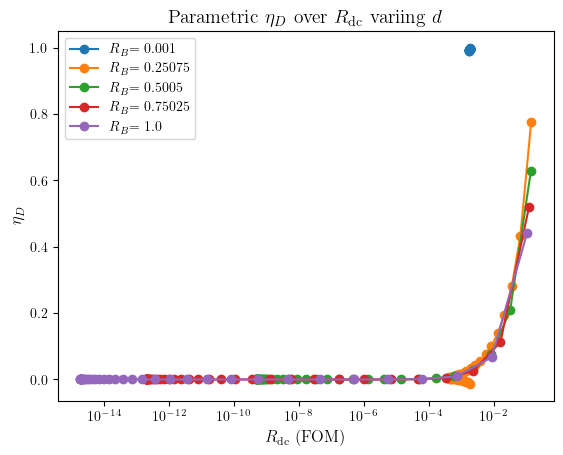

In [63]:
data=neg_virt_temp_filter(np.array(FOM_dl_RB_list_loaded))
fig, ax = plt.subplots()
ax.set_xlabel("$R_\mathrm{dc}$ (FOM)")
ax.set_ylabel("$\eta_D$")
ax.set_xscale("log")
plt.title("Parametric $\eta_D$ over $R_\mathrm{dc}$ variing $d$")
[plt.plot(np.array(data)[i,:,1],np.array(data)[i,:,0],marker="o",
          label="$R_B$= "+str(np.array(data)[i,0,out_index("rateB")]))
 for i in range(0,len(np.array(data)[:,0,0]))]
plt.legend()

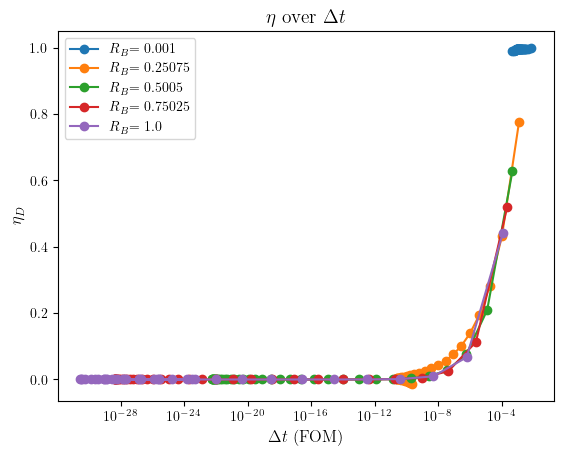

In [35]:
fig, ax = plt.subplots()
ax.set_xscale("log")

ax.set_xlabel("$\Delta t$ (FOM)")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta$ over $\Delta t$")
[plt.plot(np.array(FOM_dl_RB_list_loaded)[i,:,2],np.array(FOM_dl_RB_list_loaded)[i,:,0],marker="o",label="$R_B$= "+str(np.array(FOM_dl_RB_list_loaded)[i,0,7]))
 for i in range(0,len(FOM_dl_RB_list_loaded[:,0,7]))]
plt.legend()

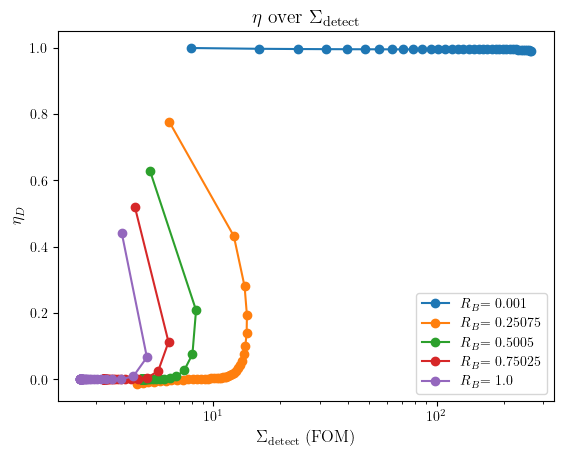

In [65]:
fig, ax = plt.subplots()
ax.set_xscale("log")

ax.set_xlabel("$\Sigma_\mathrm{detect}$ (FOM)")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta$ over $\Sigma_\mathrm{detect}$")
[plt.plot(np.array(FOM_dl_RB_list_loaded)[i,:,3],np.array(FOM_dl_RB_list_loaded)[i,:,0],marker="o",label="$R_B$= "+str(np.array(FOM_dl_RB_list_loaded)[i,0,7]))
 for i in range(0,len(FOM_dl_RB_list_loaded[:,0,7]))]
plt.legend()

### Parameter $d_L$ variation $T_H$

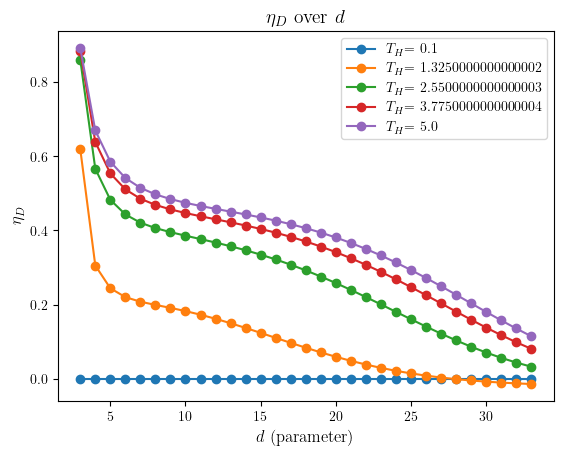

In [67]:
fig, ax = plt.subplots()
ax.set_xlabel("$d $ (parameter)")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta_D$ over $d$")
[plt.plot(np.array(FOM_dl_TH_list_loaded)[i,:,18],np.array(FOM_dl_TH_list_loaded)[i,:,0],marker="o",
          label="$T_H$= "+str(np.array(FOM_dl_TH_list_loaded)[i,0,out_index("TH")]))
 for i in range(0,len(FOM_dl_TH_list_loaded[:,0,out_index("TH")]))]
plt.legend()

#### FOM

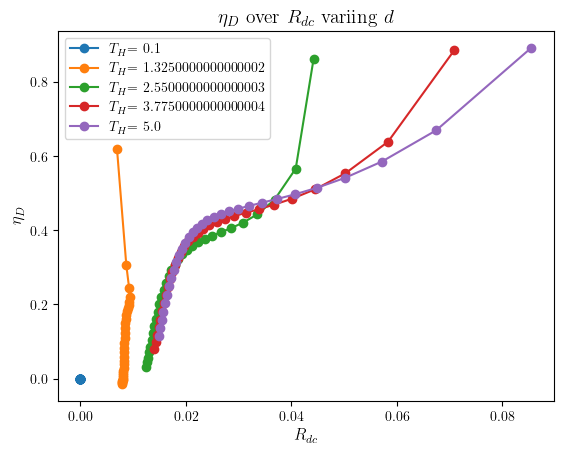

In [70]:
fig, ax = plt.subplots()
# ax.set_xscale("log")
ax.set_xlabel("$R_{dc}$ ")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta_D$ over $R_{dc}$ variing $d$")
[plt.plot(
    np.array(FOM_dl_TH_list_loaded)[i,:,out_index("dark count rate")],
    np.array(FOM_dl_TH_list_loaded)[i,:,out_index("efficiency")],
    marker="o",
    label="$T_H$= "+str(np.array(FOM_dl_TH_list_loaded)[i,0,out_index("TH")]))
 for i in range(0,len(FOM_dl_TH_list_loaded[:,0,out_index("TH")]))]
plt.legend()

### Parameter $T_C$

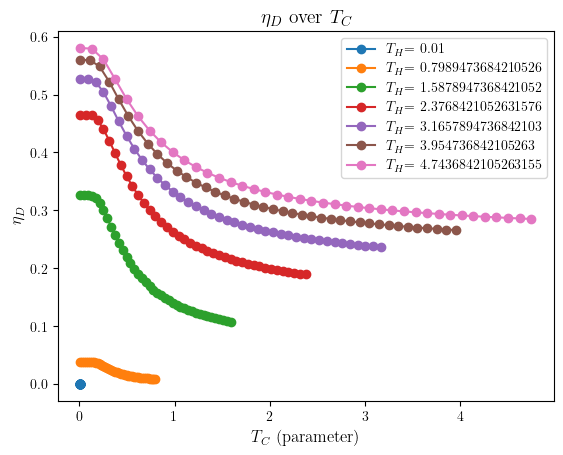

In [71]:
fig, ax = plt.subplots()
ax.set_xlabel("$T_C $ (parameter)")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta_D$ over $T_C$")
[plt.plot(np.array(FOM_TC_TH_list_loaded)[i,:,10],np.array(FOM_TC_TH_list_loaded)[i,:,0],marker="o",label="$T_H$= "+str(np.array(FOM_TC_TH_list_loaded)[i,0,out_index("TH")]))
 for i in range(0,len(FOM_TC_TH_list_loaded[:,0,out_index("TH")])-13)]
plt.legend()

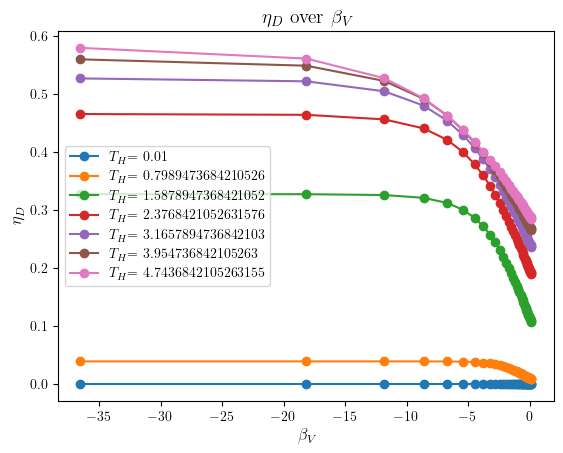

In [72]:
fig, ax = plt.subplots()
ax.set_xlabel("$\\beta_V $")
ax.set_ylabel("$\eta_D$")
plt.title("$\eta_D$ over $\\beta_V$")
[plt.plot(1/get_virtual_temp(np.array(FOM_TC_TH_list_loaded)[10,1:,9]
                 ,np.array(FOM_TC_TH_list_loaded)[10,1:,10]
                 ,np.array(FOM_TC_TH_list_loaded)[10,1:,13]
                 ,np.array(FOM_TC_TH_list_loaded)[10,1:,14]
                 )
                 ,np.array(FOM_TC_TH_list_loaded)[i,1:,0],marker="o",label="$T_H$= "+str(np.array(FOM_TC_TH_list_loaded)[i,0,9]))
 for i in range(0,len(FOM_TC_TH_list_loaded[:,0,9])-13)]
plt.legend()

##### FOM plots

### Parameter $E_{max}$

### Parameter $E_f$

# Old stuff

In [ ]:
FOM_RB_list=[get_all_figures_of_merit(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max-e_s)/(d_l-2),g_sl,g_ml,d_l,t_f,t_steps))
             for rateB in np.linspace(0.001,1,40)]

capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.


KeyboardInterrupt: 

In [6]:
FOM_dl_list=[get_all_figures_of_merit(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),g_sl,g_ml,d_l,t_f,t_steps)) for d_l in range(3,10)]

In [113]:
TC=0.01
e_H=(e_max+e_s)/(d_l-2)
e_C=0.1*e_H
temp_range=np.linspace(e_H/e_C*TC,100*e_H*TC/e_C,30)  #fixing the temperatures such that we are always in the
virt_temps=[(e_H-e_C)/(e_H/th-e_C/TC) for th in temp_range]
FOM_TV_list=[get_all_figures_of_merit(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps))
             for TH in temp_range]

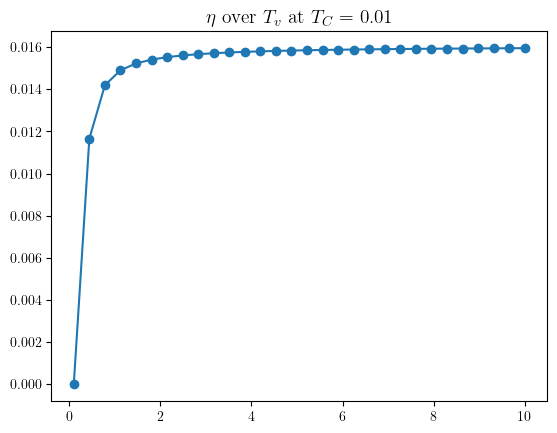

In [ ]:
plt.title("$\eta$ over $T_v$ at $T_C=0.01$")
plt.plot(temp_range,np.array(FOM_TV_list)[:,1],marker="o")
# print(get_parameterlist(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),3,t_f,t_steps)))

[['t_f', 200], ['t_steps', 1000], ['rateM', 1], ['rateB', 0.01], ['rateD', 1], ['TH', 10], ['TC', 0.1], ['Tb', 0.1], ['Td', 0.1], ['e_s', 0.1], ['e_C', 0.8], ['e_l', 0.6375], ['d_l', 3]]


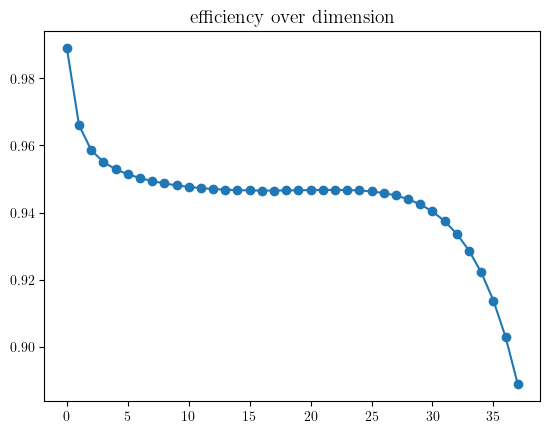

In [96]:
plt.title("efficiency over dimension")
plt.plot(np.array(FOM_dl_list)[:,0],marker="o")
print(get_parameterlist(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),3,t_f,t_steps)))


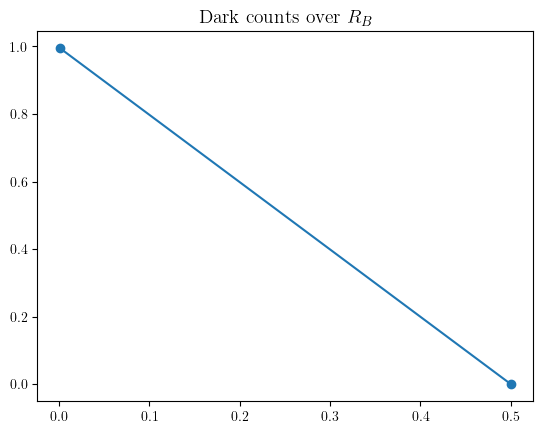

In [ ]:
plt.title("Dark counts over $R_B$")
# plt.plot([dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,50,3)],marker="o")
# plt.plot(np.linspace(0.001,0.5,len(np.array(FOM_RB_list)[:,0])),np.array(FOM_RB_list)[:,0]/(np.array(FOM_RB_list)[:,1]*np.array(FOM_RB_list)[:,2]),marker="o")
plt.plot(np.linspace(0.001,0.5,len(np.array(FOM_RB_list)[:,0])),np.array(FOM_RB_list)[:,0],marker="o")
# plt.plot(np.linspace(0.001,0.5,len(np.array(FOM_RB_list)[:,1])),np.array(FOM_RB_list)[:,1],marker="o")
# plt.plot(np.linspace(0.001,0.5,len(np.array(FOM_RB_list)[:,2])),np.array(FOM_RB_list)[:,2],marker="o")
# plt.plot(np.linspace(0.001,0.5,len(np.array(FOM_RB_list)[:,3])),np.array(FOM_RB_list)[:,3],marker="o")

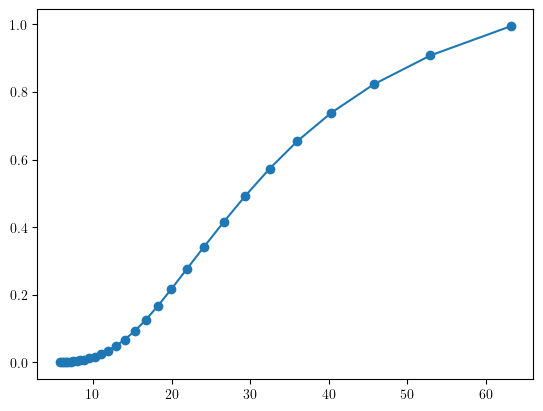

In [71]:
plt.plot(np.array(FOM_RB_list)[:,3],np.array(FOM_RB_list)[:,0],marker="o")


In [ ]:
plt.title("Dark counts over $R_B$")
# plt.plot([dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,50,3)],marker="o")
plt.plot(np.linspace(0.001,0.5,len(darkcount_RB_list)),darkcount_RB_list,marker="o")

In [34]:
print(TC,get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,3,t_f,t_steps)[10])

0.1 0.1


In [5]:
entropy_production(get_dynamics(rateM,rateB,rateD,TH,0.01,Tb,Td,e_s,e_C,e_l,3,100,1000),0.01)

TypeError: get_dynamics() missing 2 required positional arguments: 't_f' and 't_steps'

In [4]:
[plt.plot([efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,d_l,t_f,t_steps)) for d_l in range(3,15)]) for TC in np.linspace(0.01,1,5)]

TypeError: get_dynamics() missing 2 required positional arguments: 't_f' and 't_steps'

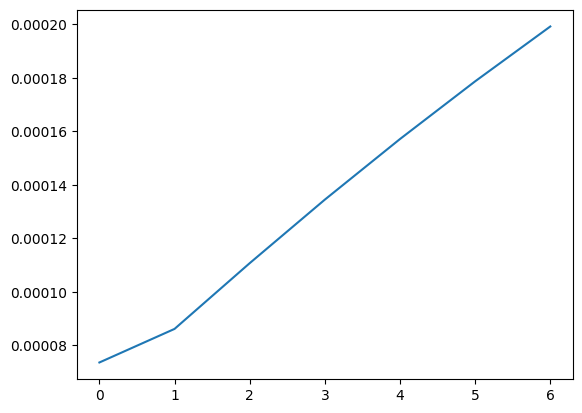

In [375]:
plt.plot([jitter(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,d_l,1000,1000)) for d_l in range(3,10)])

## Efficiency plots

In [ ]:
d_l=5

# Interaction strenghts
g_sl=1
g_ml=1

# Energies
#e_l=1/(d_l-3)
e_l=1
e_s=0.1
e_C=0.8 * e_l
e_H=e_l+e_C

e_max=10 #energy of max ladder level

t_f = 1000 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rateM=1
rateB=0.1
rateD=1

TH=10
TC=0.01
Tb=TC
Td=TC

data=[[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for e_max in np.linspace(0.2,4,20)]for d_l in range(3,8)]


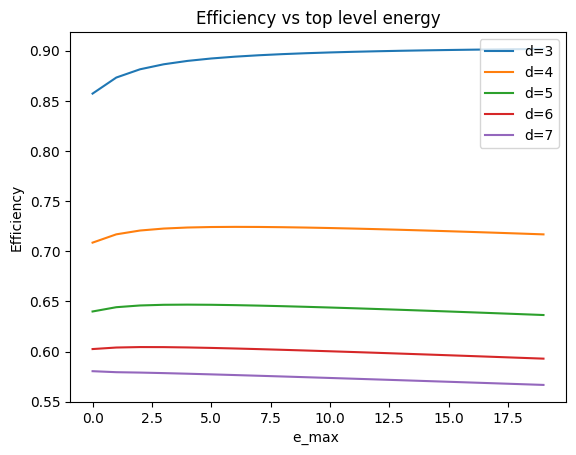

In [105]:

fig, ax = plt.subplots()
[plt.plot(dat,label="d="+str(data.index(dat)+3)) for dat in data]
ax.set_xlabel('e_max ')
ax.set_ylabel('Efficiency')
plt.title("Efficiency vs top level energy")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/detector.eps', format='eps')

## Efficiency vs Darkcounts plots

In [ ]:
d_l=10

# Interaction strenghts
g_sl=1
g_ml=1

# Energies
#e_l=1/(d_l-3)
e_l=1
e_s=0.01
e_C=0.8 * e_l
e_H=e_l+e_C

e_max=5 #energy of max ladder level

t_f = 1000 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rateM=1
rateB=0.01
rateD=1

TH=10
TC=0.1
Tb=TC
Td=TC

efficiency_list=[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,15)]
darkcount_list=[dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,15)]

list=[[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,15)],[dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,15)], for TC in np.linspace(0.1,0.5,1)]

In [202]:
list=[[[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,10)],[dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,10)]] for TC in np.linspace(0.1,0.5,5)]


In [169]:
d_l=5
efficiency_list_TC=[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for TC in np.linspace(0.001,1,20)]
darkcount_list_TC=[dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for TC in np.linspace(0.001,1,20)]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


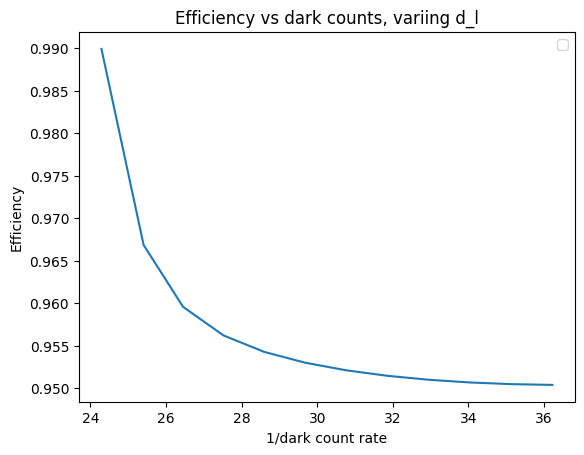

In [ ]:
fig, ax = plt.subplots()
plt.plot(1/np.array(darkcount_list),np.array(efficiency_list))
ax.set_xlabel('1/dark count rate')
ax.set_ylabel('Efficiency')
plt.title("Efficiency vs dark counts, variing d_l")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/detector.eps', format='eps')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


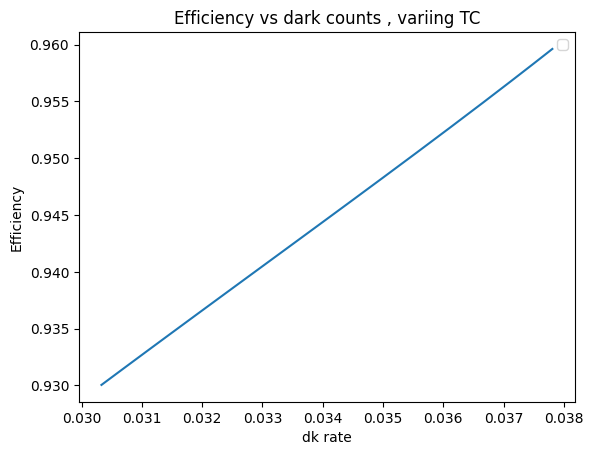

In [ ]:
fig, ax = plt.subplots()
plt.plot(np.array(darkcount_list_TC),np.array(efficiency_list_TC))
# plt.plot(np.array(efficiency_list_TC))
# plt.plot(np.array(darkcount_list_TC))

ax.set_xlabel('dk rate')
ax.set_ylabel('Efficiency')
plt.title("Efficiency vs dark counts , variing TC")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/detector.eps', format='eps')

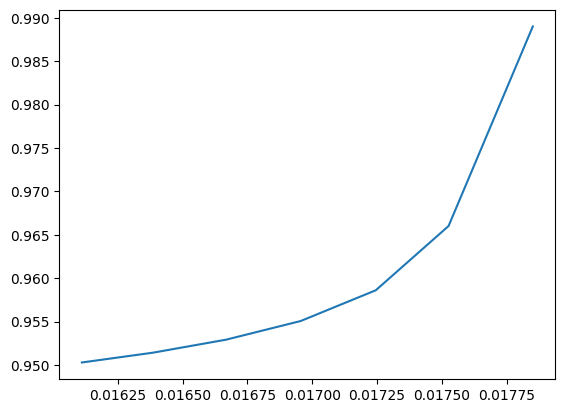

In [214]:
plt.plot(list[0][1],list[0][0])

In [126]:
list=[[[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,20)],
       [dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,20)]] for TC in np.linspace(0.5,0.5,1)]


KeyboardInterrupt: 

In [ ]:
d_l=5
# Interaction strenghts
g_sl=1
g_ml=1

# Energies
#e_l=1/(d_l-3)

e_max=5
e_s=0.1
e_C=0.8
e_l=(e_max-e_s)/(d_l-2)
e_H=e_l+e_C

t_f = 200 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rateM=1
rateB=0.01
rateD=1
TH=10
TC=0.1
Tb=TC
Td=TC
darkcount_RB_list=[dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for rateB in np.linspace(0.001,0.5,30)]

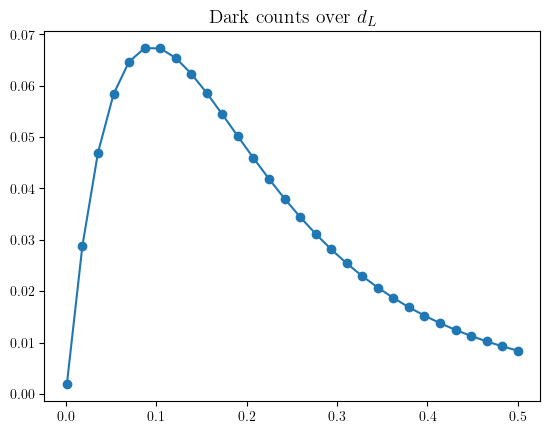

In [ ]:
plt.title("Dark counts over $R_B$")
# plt.plot([dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,50,3)],marker="o")
plt.plot(np.linspace(0.001,0.5,len(darkcount_RB_list)),darkcount_RB_list,marker="o")

In [ ]:
efficiency_RB_list=[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for rateB in np.linspace(0.001,0.5,30)]

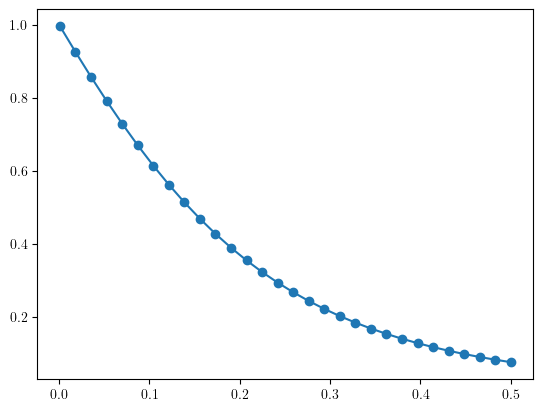

In [ ]:
plt.plot(np.linspace(0.001,0.5,len(efficiency_RB_list)),efficiency_RB_list,marker="o")

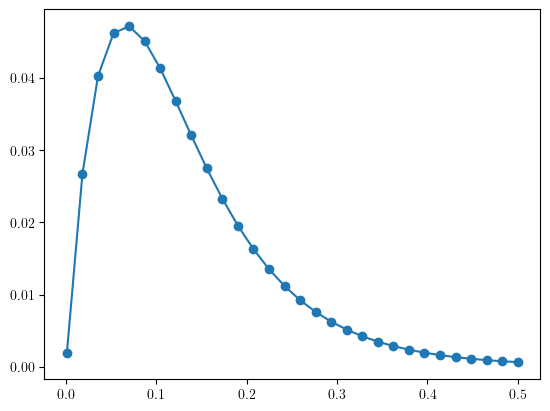

In [ ]:
plt.plot(np.linspace(0.001,0.5,len(efficiency_RB_list)),np.array(efficiency_RB_list)*np.array(darkcount_RB_list),marker="o")

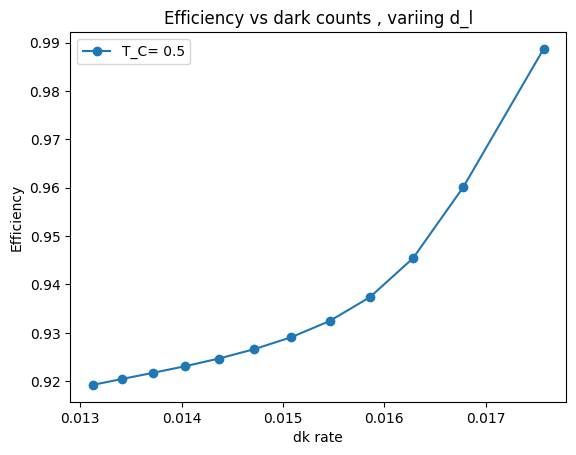

In [ ]:
fig, ax = plt.subplots()
[plt.plot(list[n][1],list[n][0],label="T_C= "+str(np.linspace(0.5,0.5,1)[n]),marker='o') for n in range(0,len(list))]
# plt.plot(np.array(efficiency_list_TC))
# plt.plot(np.array(darkcount_list_TC))

ax.set_xlabel('dk rate')
ax.set_ylabel('Efficiency')
plt.title("Efficiency vs dark counts , variing d_l")
ax.legend()
fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/Figures/eff_vs_dc_1.pdf', format='pdf')

## Entropy production

In [17]:
d_l=10

# Interaction strenghts
g_sl=1
g_ml=1

# Energies
#e_l=1/(d_l-3)
e_l=1
e_s=0.01
e_C=0.8 * e_l
e_H=e_l+e_C

e_max=5 #energy of max ladder level

t_f = 1000 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rateM=1
rateB=0.01
rateD=1

TH=10
TC=0.1
Tb=TC
Td=TC

# efficiency_list=[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,15)]
# darkcount_list=[dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,15)]

# eff_ent_list=[[efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,15)],[entropy_production(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps),TC) for d_l in range(3,15)] for TC in np.linspace(0.1,0.5,1)]
eff_ent_list = [[
    [
        efficiency(get_dynamics(rateM, rateB, rateD, TH, TC, Tb, Td, e_s, e_C, (e_max + e_s) / (d_l - 2), d_l, t_f, t_steps))
        for TC in np.linspace(0.1, 0.5, 10)
    ],
    [
        entropy_production(get_dynamics(rateM, rateB, rateD, TH, TC, Tb, Td, e_s, e_C, (e_max + e_s) / (d_l - 2), d_l, t_f, t_steps), TC)
        for TC in np.linspace(0.1, 0.5, 10)
    ]]
    for d_l in range(3, 8)]


capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.


KeyboardInterrupt: 

NameError: name 'eff_ent_list' is not defined

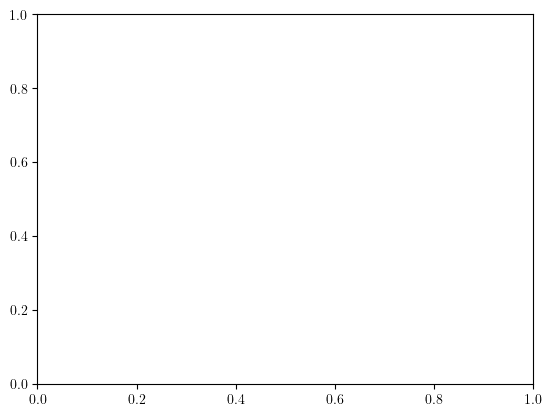

In [ ]:
fig, ax = plt.subplots()
[plt.plot(np.array(eff_ent_list[n][1]),np.array(eff_ent_list[n][0]),label="$d_l$= "+str(n+3)) for n in range(0,len(eff_ent_list))]
# plt.plot(np.array(efficiency_list_TC))
# plt.plot(np.array(darkcount_list_TC))

ax.set_xlabel('entropy produced')
ax.set_ylabel('Efficiency')
plt.title("Efficiency vs entropy prod. , variing TC")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/Figures/eff_vs_dc_1.pdf', format='pdf')

## Jitter vs Dark count rate, entropy and efficency

In [ ]:
# plt.plot([jitter(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,d_l,1000,1000)) for d_l in range(3,10)])

# d_l=5
# efficiency_list_TC=[jitter(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for TC in np.linspace(0.001,1,20)]
# darkcount_list_TC=[dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for TC in np.linspace(0.001,1,20)]

jitter_dc_list_TC=[[
    [jitter(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,10)],
    [dark_counts(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,10)]]
      for TC in np.linspace(0.1,0.5,5)]


KeyboardInterrupt: 

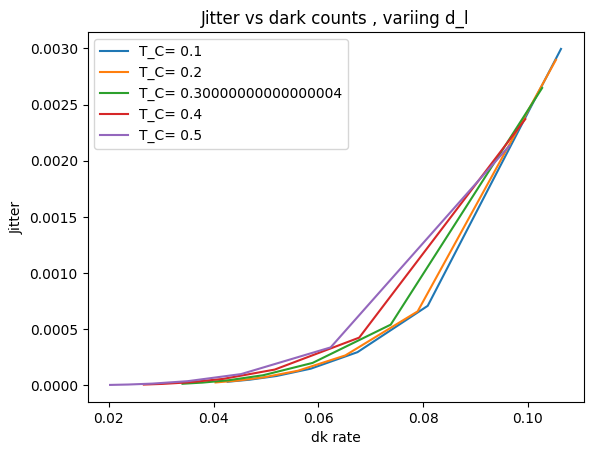

In [ ]:
fig, ax = plt.subplots()
[plt.plot(jitter_dc_list_TC[n][1],jitter_dc_list_TC[n][0],label="T_C= "+str(np.linspace(0.1,0.5,5)[n])) for n in range(0,len(jitter_dc_list_TC))]
# plt.plot(np.array(efficiency_list_TC))
# plt.plot(np.array(darkcount_list_TC))

ax.set_xlabel('dc rate')
ax.set_ylabel('Jitter')
plt.title("Jitter vs dark counts , variing d_l")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/Figures/eff_vs_dc_1.pdf', format='pdf')

In [23]:
jitter_ent_list = [[
    [
        jitter(get_dynamics(rateM, rateB, rateD, TH, TC, Tb, Td, e_s, e_C, (e_max + e_s) / (d_l - 2), d_l, t_f, t_steps))
        for TC in np.linspace(0.1, 0.5, 10)
    ],
    [
        entropy_production(get_dynamics(rateM, rateB, rateD, TH, TC, Tb, Td, e_s, e_C, (e_max + e_s) / (d_l - 2), d_l, t_f, t_steps), TC)
        for TC in np.linspace(0.1, 0.5, 10)
    ]]
    for d_l in range(3, 10)]

IndexError: index 5 is out of bounds for axis 0 with size 5

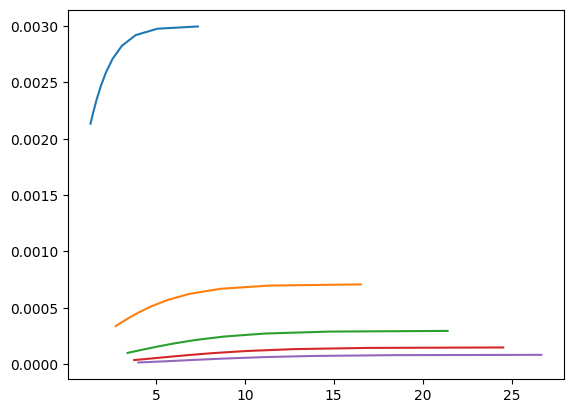

In [24]:
fig, ax = plt.subplots()
[plt.plot(jitter_ent_list[n][1],jitter_ent_list[n][0],label="T_C= "+str(np.linspace(0.1,0.5,5)[n])) for n in range(0,len(jitter_ent_list))]
# plt.plot(np.array(efficiency_list_TC))
# plt.plot(np.array(darkcount_list_TC))

ax.set_xlabel('entropy prod')
ax.set_ylabel('Jitter')
plt.title("Jitter vs entropy prod , variing d_l")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/Figures/eff_vs_dc_1.pdf', format='pdf')

In [25]:
jitter_eff_list_TC=[[
    [jitter(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,10)],
    [efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,10)]]
      for TC in np.linspace(0.1,0.5,5)]

In [ ]:
[a**2;]

In [78]:
jitter_eff_list_TC

[[[0.0029956352435326545,
   0.000707280940987749,
   0.0002947640435059857,
   0.0001478211296104403,
   8.230275443351276e-05,
   4.9193040110953724e-05,
   3.1022589522629235e-05],
  [0.8986186017440646,
   0.7092058398926852,
   0.6278679762797261,
   0.583137486696906,
   0.5553561781438556,
   0.5365434728126507,
   0.5228841695970797]],
 [[0.002898775342833613,
   0.0006580694304369015,
   0.00026552754102157817,
   0.00012931838264098117,
   6.99857034181936e-05,
   4.065307256314355e-05,
   2.491588188077292e-05],
  [0.8983653576401794,
   0.7057669286405229,
   0.6206646809526317,
   0.5730754988283708,
   0.5431874551622708,
   0.5227850466374977,
   0.5078429345953331]],
 [[0.0026478095285911636,
   0.0005397368641144397,
   0.00019891065592099672,
   8.912852042637672e-05,
   4.442268218603335e-05,
   2.3701218688809546e-05,
   1.3318729487416998e-05],
  [0.8976457337665762,
   0.6961111973335573,
   0.6004055938603783,
   0.5445293535477403,
   0.5083174376123847,
   0.48

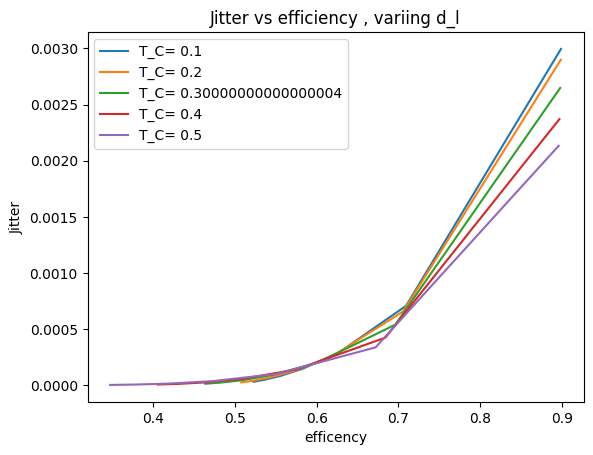

In [26]:
fig, ax = plt.subplots()
[plt.plot(jitter_eff_list_TC[n][1],jitter_eff_list_TC[n][0],label="T_C= "+str(np.linspace(0.1,0.5,5)[n])) for n in range(0,len(jitter_eff_list_TC))]
# plt.plot(np.array(efficiency_list_TC))
# plt.plot(np.array(darkcount_list_TC))

ax.set_xlabel('efficency')
ax.set_ylabel('Jitter')
plt.title("Jitter vs efficiency , variing d_l")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/Figures/eff_vs_dc_1.pdf', format='pdf')

## $H=\eta /(D \Delta t)$ vs other stuff

In [ ]:
jitter_eff_list_TC=[[
    [jitter(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,10)],
    [efficiency(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for d_l in range(3,10)]]
      for TC in np.linspace(0.1,0.5,5)]

In [ ]:
# H_ent_list_TC=[[
#     [entropy_production(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)) for dyn in (get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps) for d_l in range(3,10))],
#     [np.array(efficiency(dynamics))/(np.array(jitter(dynamics))*dark_counts(dynamics)) for d_l in range(3,10)]]
#       for TC in np.linspace(0.1,0.5,5)]

H_ent_list_TC=[]
for TC in np.linspace(0.1,0.5,5):
    d_list=[[],[]]
    for d_l in range(3,10):
        dynamics=get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps)
        d_list=np.append(d_list,[[np.array(efficiency(dynamics))/(np.array(jitter(dynamics))*dark_counts(dynamics))],[entropy_production(dynamics,TC)]],axis=1)

    H_ent_list_TC=np.append(H_ent_list_TC,d_list,axis=0)
    print(H_ent_list_TC)


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)

In [87]:
H_ent_list_TC

array([[2.82210167e+03, 1.23998799e+04, 3.15701665e+04, 6.73483418e+04,
        1.29744272e+05, 2.32740436e+05, 3.94830371e+05, 2.94214619e+03,
        1.35840553e+04, 3.58808860e+04, 7.89774008e+04, 1.56659944e+05,
        2.89229855e+05, 5.04759550e+05, 3.30113320e+03, 1.74744599e+04,
        5.12456899e+04, 1.23492576e+05, 2.66931361e+05, 5.37190489e+05,
        1.02177254e+06, 3.80210372e+03, 2.37898429e+04, 7.97123985e+04,
        2.16154865e+05, 5.23145194e+05, 1.18057399e+06, 2.51883553e+06,
        4.35480041e+03, 3.19734921e+04, 1.22238424e+05, 3.73212285e+05,
        1.01137660e+06, 2.55459651e+06, 6.09298671e+06],
       [7.36720088e+00, 1.65214944e+01, 2.13998760e+01, 2.45280684e+01,
        2.66751881e+01, 2.82027739e+01, 2.93066048e+01, 3.64793425e+00,
        8.11836548e+00, 1.04871260e+01, 1.19996628e+01, 1.30341078e+01,
        1.37647274e+01, 1.42835339e+01, 2.36697623e+00, 5.15562777e+00,
        6.59916152e+00, 7.50362910e+00, 8.11283967e+00, 8.53129178e+00,
       

In [90]:
H_ent_list_TC[0][1]

12399.879855280464

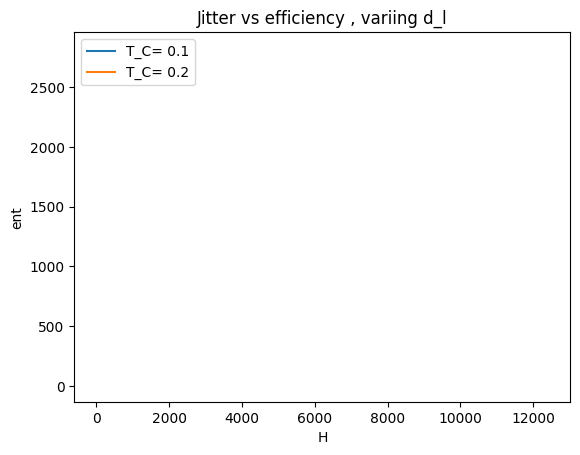

In [88]:
fig, ax = plt.subplots()
[plt.plot(H_ent_list_TC[n][1],H_ent_list_TC[n][0],label="T_C= "+str(np.linspace(0.1,0.5,5)[n])) for n in range(0,len(H_ent_list_TC))]
# plt.plot(np.array(efficiency_list_TC))
# plt.plot(np.array(darkcount_list_TC))

ax.set_xlabel('H')
ax.set_ylabel('ent')
plt.title("Jitter vs efficiency , variing d_l")
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/Figures/eff_vs_dc_1.pdf', format='pdf')

## Rest

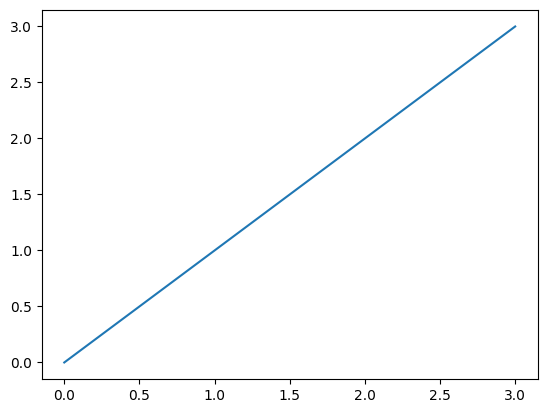

In [107]:
plt.plot([0,1,2,3],[0,1,2,3])

[[<matplotlib.lines.Line2D at 0x74dae9060670>],

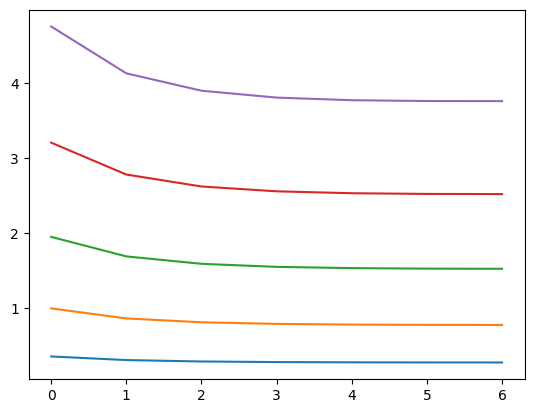

In [89]:
[plt.plot([energy_out(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,(e_max+e_s)/(d_l-2),d_l,t_f,t_steps),(e_max+e_s)/(d_l-2),e_s,d_l) for d_l in range(3,10)]) for e_max in np.linspace(0.1,2,5)]

[[<matplotlib.lines.Line2D at 0x75f7f5f15300>],

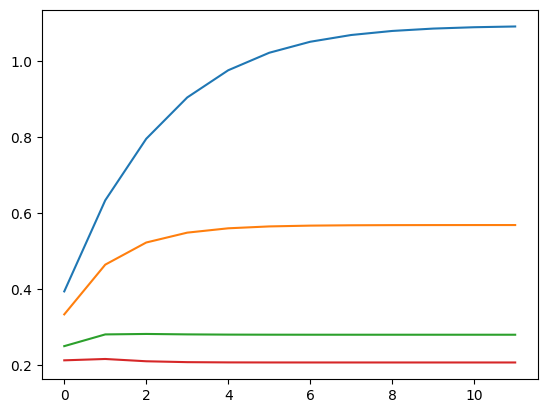

In [ ]:
[plt.plot([entropy_production(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,d_l,t_f,t_steps)) for d_l in range(3,15)]) for TC in np.linspace(0.01,1,4)]

[[<matplotlib.lines.Line2D at 0x75f7f5e49cc0>],

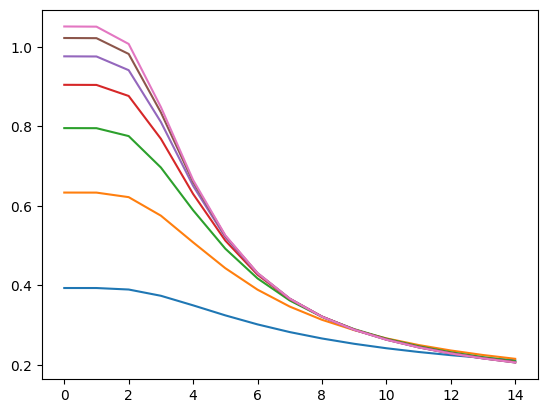

In [ ]:
[plt.plot([entropy_production(get_dynamics(rateM,rateB,rateD,TH,TC,Tb,Td,e_s,e_C,e_l,d_l,t_f,t_steps)) for TC in np.linspace(0.01,1,15) ]) for d_l in range(3,10) ]


In [40]:
ptrace(steady_prev_run,2)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.4555229  0.         0.         0.        ]
 [0.         0.39130435 0.         0.        ]
 [0.         0.         0.1254721  0.        ]
 [0.         0.         0.         0.02770065]]